In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys, os

sys.path.insert(1,'../')

from VI_solvers.rad_vi import RadVI 
from VI_solvers.laplace_approx import laplace_from_potential
from VI_solvers.gaussian_fbvi import Gaussian_FBVI

from utils.elliptical_distributions import MultivariateGaussian, MultivariateLaplace, MultivariateStudent, MultivariateLogistic 
from utils.transport_maps import GaussianToLaplaceOTMap, GaussianToLogisticOTMap, student_t_map
from utils.wasserstein_distance import w2_squared_radial_from_points

In [2]:
plt.rcParams.update({"text.usetex": True})
plt.rcParams.update({"font.family": "serif", "font.serif": "Computer Modern"})

np.random.seed(1)

if not os.path.exists('plots/convergence'):
    os.makedirs('plots/convergence')

In [3]:
### Define target distribution parameters
dim = 50

target_mean = np.zeros((dim, 1))
target_cov  = np.eye(dim)
target_scale = 1 # for logistic distribution
target_dof = 10  # for student-t distribution

## Laplace

In [4]:
### Define distribution
target_distribution_laplace = MultivariateLaplace(target_mean, target_cov)
V_laplace                   = lambda x: target_distribution_laplace.potential(x)
gradV_laplace               = lambda x: target_distribution_laplace.grad_potential(x)
hessV_laplace               = lambda x: target_distribution_laplace.hess_potential(x)

In [5]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
alpha = 0.01
if dim == 100:
    mesh = 1/(dim**(1/8))
elif dim == 50:
    mesh = 1/(dim**(1/6))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
learning_rate = 5e-3
if dim == 100:
    n_iterations  = 5000 * 4
elif dim == 50:
    n_iterations  = 5000 * 2
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

### Define true optimal transport map
radial_map_laplace = lambda r: GaussianToLaplaceOTMap(dim=dim).transform(r)

In [6]:
### Fit Laplace approximation
mean_laplace_approx_laplace, cov_laplace_approx_laplace = laplace_from_potential(V=V_laplace, 
                                                                                 grad_V=gradV_laplace, 
                                                                                 hess_V=hessV_laplace,
                                                                                 x0=np.ones(dim),
                                                                                 method='BFGS')

### Fit Gaussian VI
FBVI_laplace = Gaussian_FBVI(learning_rate=learning_rate, 
                             dim=dim,
                             grad_V=gradV_laplace,
                             hess_V=hessV_laplace,
                             mean=np.zeros((dim, 1)),
                             covariance=np.eye(dim))

FBVI_laplace.fit(num_iterations=n_iterations, sample_size=n_samples_sgd, print_freq=2500)

mean_fbvi_approx_laplace = FBVI_laplace.mean.real
cov_fbvi_approx_laplace  = FBVI_laplace.sigma.real

### Fit radVI
RadVI_laplace = RadVI(truncation=truncation, 
                      mesh=mesh, 
                      dim=dim, 
                      alpha=alpha, 
                      isotropic=True,
                      V=V_laplace,
                      grad_V=gradV_laplace,
                      N_mc=n_samples_mc,
                      radial_ot_map=radial_map_laplace)

RadVI_laplace.fit(learning_rate=learning_rate,
                  num_iterations=n_iterations, 
                  sample_size=n_samples_sgd,
                  compute_wasserstein=True,
                  print_freq=2500,
                  log_w2_freq=10)

--------------------------------------------------
       Fitting Laplace Approximation 
--------------------------------------------------
• Method: BFGS
--------------------------------------------------

Using provided closed-form Hessian of the potential function
Completed fitting Laplace approximation.


--------------------------------------------------
       Fitting Gaussian FBVI Approximation 
--------------------------------------------------
Optimizer settings:
• Learning rate   : 0.005
• Iterations      : 10000
• Sample size     : 100
--------------------------------------------------

Iteration 2500 of 10000
Iteration 5000 of 10000
Iteration 7500 of 10000
Iteration 10000 of 10000
Completed fitting Gaussian FBVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.01
• Num. ba

## Logistic

In [7]:
### Define distribution
target_distribution_logistic = MultivariateLogistic(target_mean, target_cov, scale=target_scale)
V_logistic                   = lambda x: target_distribution_logistic.potential(x)
gradV_logistic               = lambda x: target_distribution_logistic.grad_potential(x)
hessV_logistic               = lambda x: target_distribution_logistic.hess_potential(x)

In [8]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
alpha = 0.01
if dim == 100:
    mesh = 1/(dim**(1/8))
elif dim == 50:
    mesh = 1/(dim**(1/6))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
learning_rate = 5e-2
if dim == 100:
    n_iterations  = 5000 * 4
elif dim == 50:
    n_iterations  = 5000 * 2
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

### Define true optimal transport map
radial_map_logistic = lambda r: GaussianToLogisticOTMap(dim=dim).transform(r)

In [9]:
## Fit Laplace approximation
mean_laplace_approx_logistic, cov_laplace_approx_logistic = laplace_from_potential(V=V_logistic, 
                                                                                   grad_V=gradV_logistic, 
                                                                                   hess_V=hessV_logistic,
                                                                                   x0=np.ones(dim),
                                                                                   method='BFGS')

## Fit Gaussian VI 
FBVI_logistic = Gaussian_FBVI(learning_rate=learning_rate, 
                              dim=dim,
                              grad_V=gradV_logistic,
                              hess_V=hessV_logistic,
                              mean=np.zeros((dim, 1)),
                              covariance=np.eye(dim))

FBVI_logistic.fit(num_iterations=n_iterations, sample_size=n_samples_sgd, print_freq=2500)

mean_fbvi_approx_logistic = FBVI_logistic.mean.real
cov_fbvi_approx_logistic  = FBVI_logistic.sigma.real

### Fit radVI
RadVI_logistic = RadVI(truncation=truncation, 
                      mesh=mesh, 
                      dim=dim, 
                      alpha=alpha, 
                      isotropic=True,
                      V=V_logistic,
                      grad_V=gradV_logistic, 
                      N_mc=n_samples_mc,
                      radial_ot_map=radial_map_logistic)

RadVI_logistic.fit(learning_rate=learning_rate,
                   num_iterations=n_iterations, 
                   sample_size=n_samples_sgd,
                   compute_wasserstein=True,
                   print_freq=2500,
                   log_w2_freq=10)

--------------------------------------------------
       Fitting Laplace Approximation 
--------------------------------------------------
• Method: BFGS
--------------------------------------------------

Using provided closed-form Hessian of the potential function
Completed fitting Laplace approximation.


--------------------------------------------------
       Fitting Gaussian FBVI Approximation 
--------------------------------------------------
Optimizer settings:
• Learning rate   : 0.05
• Iterations      : 10000
• Sample size     : 100
--------------------------------------------------

Iteration 2500 of 10000
Iteration 5000 of 10000
Iteration 7500 of 10000
Iteration 10000 of 10000
Completed fitting Gaussian FBVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.01
• Num. bas

## Student-t

In [10]:
### Define distribution
target_distribution_student = MultivariateStudent(target_mean, target_cov, dof=target_dof)
V_student                   = lambda x: target_distribution_student.potential(x)
gradV_student               = lambda x: target_distribution_student.grad_potential(x)
hessV_student               = lambda x: target_distribution_student.hess_potential(x)

In [11]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
alpha = 0.01
if dim == 100:
    mesh = 1/(dim**(1/8))
elif dim == 50:
    mesh = 1/(dim**(1/6))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
learning_rate = 7e-3
if dim == 100:
    n_iterations  = 5000 * 4
elif dim == 50:
    n_iterations  = 5000 * 2
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

### Define true optimal transport map
radial_map_student = lambda r: student_t_map(r, dof=target_dof, dim=dim)

In [12]:
### Fit Laplace approximation
mean_laplace_approx_student, cov_laplace_approx_student = laplace_from_potential(V=V_student, 
                                                                                 grad_V=gradV_student, 
                                                                                 hess_V=hessV_student,
                                                                                 x0=np.ones(dim),
                                                                                 method='BFGS')

### Fit Gaussian VI
FBVI_student = Gaussian_FBVI(learning_rate=learning_rate, 
                             dim=dim,
                             grad_V=gradV_student,
                             hess_V=hessV_student,
                             mean=np.zeros((dim, 1)),
                             covariance=np.eye(dim))

FBVI_student.fit(num_iterations=n_iterations, sample_size=n_samples_sgd, print_freq=2500)

mean_fbvi_approx_student = FBVI_student.mean.real
cov_fbvi_approx_student  = FBVI_student.sigma.real

### Fit radVI
RadVI_student = RadVI(truncation=truncation, 
                      mesh=mesh, 
                      dim=dim, 
                      alpha=alpha, 
                      isotropic=True,
                      V=V_student,
                      grad_V=gradV_student, 
                      N_mc=n_samples_mc,
                      radial_ot_map=radial_map_student)

RadVI_student.fit(learning_rate=learning_rate,
                  num_iterations=n_iterations, 
                  sample_size=n_samples_sgd,
                  compute_wasserstein=True,
                  print_freq=2500,
                  log_w2_freq=10)

--------------------------------------------------
       Fitting Laplace Approximation 
--------------------------------------------------
• Method: BFGS
--------------------------------------------------

Using provided closed-form Hessian of the potential function
Completed fitting Laplace approximation.


--------------------------------------------------
       Fitting Gaussian FBVI Approximation 
--------------------------------------------------
Optimizer settings:
• Learning rate   : 0.007
• Iterations      : 10000
• Sample size     : 100
--------------------------------------------------

Iteration 2500 of 10000
Iteration 5000 of 10000
Iteration 7500 of 10000
Iteration 10000 of 10000
Completed fitting Gaussian FBVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.01
• Num. ba

## Gaussian

In [13]:
### Define distribution
target_distribution_gaussian = MultivariateGaussian(target_mean, target_cov)
V_gaussian                   = lambda x: target_distribution_gaussian.potential(x)
gradV_gaussian               = lambda x: target_distribution_gaussian.grad_potential(x)
hessV_gaussian               = lambda x: target_distribution_gaussian.hess_potential(x)

In [14]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
alpha = 0.01
if dim == 100:
    mesh = 1/(dim**(1/8))
elif dim == 50:
    mesh = 1/(dim**(1/6))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
learning_rate = 5e-3
if dim == 100:
    n_iterations  = 5000 * 4
elif dim == 50:
    n_iterations  = 5000 * 2
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

### Define true optimal transport map
radial_map_gaussian = lambda r: r

In [15]:
### Fit Laplace approximation
mean_laplace_approx_gaussian, cov_laplace_approx_gaussian = laplace_from_potential(V=V_gaussian, 
                                                                                   grad_V=gradV_gaussian, 
                                                                                   hess_V=hessV_gaussian,
                                                                                   x0=np.ones(dim),
                                                                                   method='BFGS')

### Fit Gaussian VI
FBVI_gaussian = Gaussian_FBVI(learning_rate=learning_rate, 
                             dim=dim,
                             grad_V=gradV_gaussian,
                             hess_V=hessV_gaussian,
                             mean=np.zeros((dim, 1)),
                             covariance=np.eye(dim))

FBVI_gaussian.fit(num_iterations=n_iterations, sample_size=n_samples_sgd, print_freq=2500)

mean_fbvi_approx_gaussian = FBVI_gaussian.mean.real
cov_fbvi_approx_gaussian  = FBVI_gaussian.sigma.real

### Fit radVI
RadVI_gaussian = RadVI(truncation=truncation, 
                      mesh=mesh, 
                      dim=dim, 
                      alpha=alpha, 
                      isotropic=True,
                      V=V_gaussian,
                      grad_V=gradV_gaussian, 
                      N_mc=n_samples_mc,
                      radial_ot_map=radial_map_gaussian)

RadVI_gaussian.fit(learning_rate=learning_rate,
                   num_iterations=n_iterations, 
                   sample_size=n_samples_sgd,
                   compute_wasserstein=True,
                   print_freq=2500,
                   log_w2_freq=10)

--------------------------------------------------
       Fitting Laplace Approximation 
--------------------------------------------------
• Method: BFGS
--------------------------------------------------

Using provided closed-form Hessian of the potential function
Completed fitting Laplace approximation.


--------------------------------------------------
       Fitting Gaussian FBVI Approximation 
--------------------------------------------------
Optimizer settings:
• Learning rate   : 0.005
• Iterations      : 10000
• Sample size     : 100
--------------------------------------------------

Iteration 2500 of 10000
Iteration 5000 of 10000
Iteration 7500 of 10000
Iteration 10000 of 10000
Completed fitting Gaussian FBVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.01
• Num. ba

## Compute $W_2^2$ Distance Between Target and Approximation Samples 

In [16]:
### Generate samples for Laplace
target_data      = target_distribution_laplace.sample(n_samples_mc)
laplace_data_LA  = np.random.multivariate_normal(mean=mean_laplace_approx_laplace.flatten(), cov=cov_laplace_approx_laplace, size=n_samples_mc).T
laplace_data_GVI = np.random.multivariate_normal(mean=mean_fbvi_approx_laplace.flatten(), cov=cov_fbvi_approx_laplace, size=n_samples_mc).T

w2_laplace_LA  = w2_squared_radial_from_points(target_data, laplace_data_LA)
w2_laplace_GVI = w2_squared_radial_from_points(target_data, laplace_data_GVI)

### Generate samples for Logistic
target_data_logistic = target_distribution_logistic.sample(n_samples_mc)
logistic_data_LA    = np.random.multivariate_normal(mean=mean_laplace_approx_logistic.flatten(), cov=cov_laplace_approx_logistic, size=n_samples_mc).T
logistic_data_GVI   = np.random.multivariate_normal(mean=mean_fbvi_approx_logistic.flatten(), cov=cov_fbvi_approx_logistic, size=n_samples_mc).T

w2_laplace_logistic = w2_squared_radial_from_points(target_data_logistic, logistic_data_LA)
w2_fbvi_logistic    = w2_squared_radial_from_points(target_data_logistic, logistic_data_GVI)

### Generate samples for Student-t
target_data_student = target_distribution_student.sample(n_samples_mc)
student_data_LA     = np.random.multivariate_normal(mean=mean_laplace_approx_student.flatten(), cov=cov_laplace_approx_student, size=n_samples_mc).T
student_data_GVI    = np.random.multivariate_normal(mean=mean_fbvi_approx_student.flatten(), cov=cov_fbvi_approx_student, size=n_samples_mc).T

w2_laplace_student = w2_squared_radial_from_points(target_data_student, student_data_LA)
w2_fbvi_student    = w2_squared_radial_from_points(target_data_student, student_data_GVI)

### Generate samples for Gaussian
target_data_gaussian = target_distribution_gaussian.sample(n_samples_mc)
gaussian_data_LA     = np.random.multivariate_normal(mean=mean_laplace_approx_gaussian.flatten(), cov=cov_laplace_approx_gaussian, size=n_samples_mc).T
gaussian_data_GVI    = np.random.multivariate_normal(mean=mean_fbvi_approx_gaussian.flatten(), cov=cov_fbvi_approx_gaussian, size=n_samples_mc).T

w2_laplace_gaussian = w2_squared_radial_from_points(target_data_gaussian, gaussian_data_LA)
w2_fbvi_gaussian    = w2_squared_radial_from_points(target_data_gaussian, gaussian_data_GVI)

print("==== 2-Wasserstein Distances (W2^2) for Each Target Distribution ====")
print("{:<15} {:>20} {:>20}".format("Target", "Laplace Approx.", "Gaussian VI"))
print("-" * 60)
print("{:<15} {:>20.6f} {:>20.6f}".format("Gaussian", w2_laplace_gaussian, w2_fbvi_gaussian))
print("{:<15} {:>20.6f} {:>20.6f}".format("Laplace", w2_laplace_LA, w2_laplace_GVI))
print("{:<15} {:>20.6f} {:>20.6f}".format("Logistic", w2_laplace_logistic, w2_fbvi_logistic))
print("{:<15} {:>20.6f} {:>20.6f}".format("Student-t", w2_laplace_student, w2_fbvi_student))
print("=" * 60)

==== 2-Wasserstein Distances (W2^2) for Each Target Distribution ====
Target               Laplace Approx.          Gaussian VI
------------------------------------------------------------
Gaussian                    0.000340             0.000552
Laplace                    20.488910             7.766169
Logistic                 1629.566059             4.265279
Student-t                  26.343501             2.273766


/var/folders/_2/kk0m1klx7vjdmxtw2ms6f8400000gn/T/ipykernel_15456/4124552153.py:3: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  laplace_data_LA  = np.random.multivariate_normal(mean=mean_laplace_approx_laplace.flatten(), cov=cov_laplace_approx_laplace, size=n_samples_mc).T


## Plot $W_2^2$ Convergence of radVI

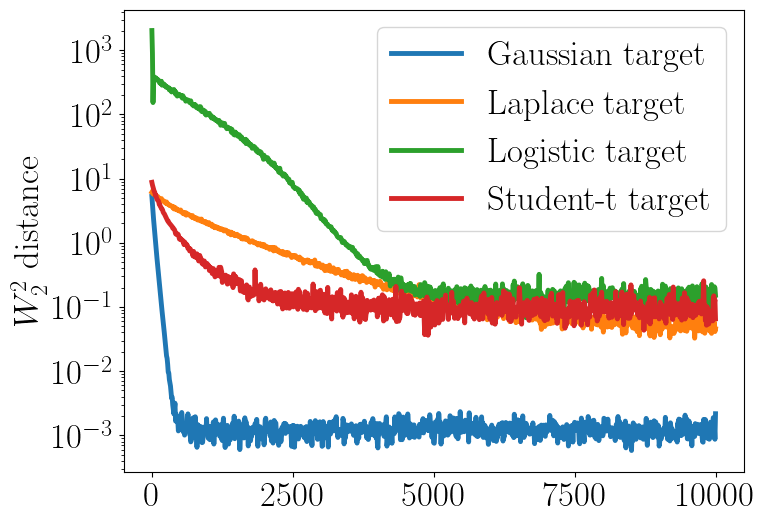

In [17]:
iterations_gaussian = np.arange(0, len(RadVI_gaussian.wasserstein_history)*10, 10)
iterations_laplace = np.arange(0, len(RadVI_laplace.wasserstein_history)*10, 10)
iterations_logistic = np.arange(0, len(RadVI_logistic.wasserstein_history)*10, 10)
iterations_student = np.arange(0, len(RadVI_student.wasserstein_history)*10, 10)

plt.figure(figsize=(8,6))
plt.semilogy(iterations_gaussian, RadVI_gaussian.wasserstein_history, label='Gaussian target',linewidth=3.5)
plt.semilogy(iterations_laplace, RadVI_laplace.wasserstein_history, label='Laplace target',linewidth=3.5)
plt.semilogy(iterations_logistic, RadVI_logistic.wasserstein_history, label='Logistic target',linewidth=3.5)
plt.semilogy(iterations_student, RadVI_student.wasserstein_history, label='Student-t target',linewidth=3.5)

plt.ylabel(r'$W_2^2$ distance', fontsize=25)
plt.xticks(np.arange(0, 12500, 2500),fontsize=25)
plt.yticks(fontsize=25)
plt.legend(markerscale=7,fontsize=25)
plt.savefig(f'plots/convergence/isotropic_convergence_dim{dim}.pdf', dpi=300, bbox_inches='tight')
plt.show()